# Predicting House Prices with Linear Regression

## Level 2 – Task 1

### Project Objective

The objective of this project is to build and evaluate a Linear Regression model capable of predicting house prices using housing characteristics, location-related variables, property age, room information and income-related features.

The project follows an end-to-end machine learning workflow, including:

- Exploratory Data Analysis
- Data cleaning
- Missing value handling
- Feature selection
- Categorical variable encoding
- Model training
- Model evaluation
- Prediction visualisation
- Residual analysis
- Coefficient interpretation
- Regularisation model comparison

### Dataset

This project uses the California Housing dataset.

The target variable is:

**median_house_value**

The dataset includes numerical variables describing housing characteristics and a categorical location-related feature called **ocean_proximity**.

Because the dataset does not contain a direct property-area measurement, variables such as **total_rooms** and **total_bedrooms** are used as proxy indicators of property size.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Loading the Dataset

The dataset is loaded using pandas. An initial inspection is performed to understand its structure, column names and data types before beginning the analysis.

In [2]:
df = pd.read_csv("housing.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nFirst Five Rows:")
display(df.head())

print("\nLast Five Rows:")
display(df.tail())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape:
(20640, 10)

First Five Rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



Last Five Rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND



Column Names:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


## 2. Initial Data Quality Assessment

Before developing a machine learning model, it is important to examine the quality of the dataset.

The following checks are performed:

- Missing values
- Duplicate records
- Data types
- Descriptive statistics

In [4]:
# Missing Values

missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull()
    .mean()
    .mul(100)
    .round(2)
)

missing_report = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

display(
    missing_report[
        missing_report["Missing Values"] > 0
    ]
)

,Missing Values,Missing Percentage
total_bedrooms,207,1.0


In [5]:
# Duplicate Records

duplicate_count = df.duplicated().sum()

print(
    f"Number of duplicate rows: {duplicate_count}"
)

Number of duplicate rows: 0


## 3. Descriptive Statistics

Descriptive statistics are calculated to understand the central tendency and distribution of the numerical housing variables.

The analysis includes:

- Count
- Mean
- Standard deviation
- Minimum value
- Quartiles
- Maximum value

In [6]:
display(
    df.describe().T
)

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


## 4. Distribution of House Prices


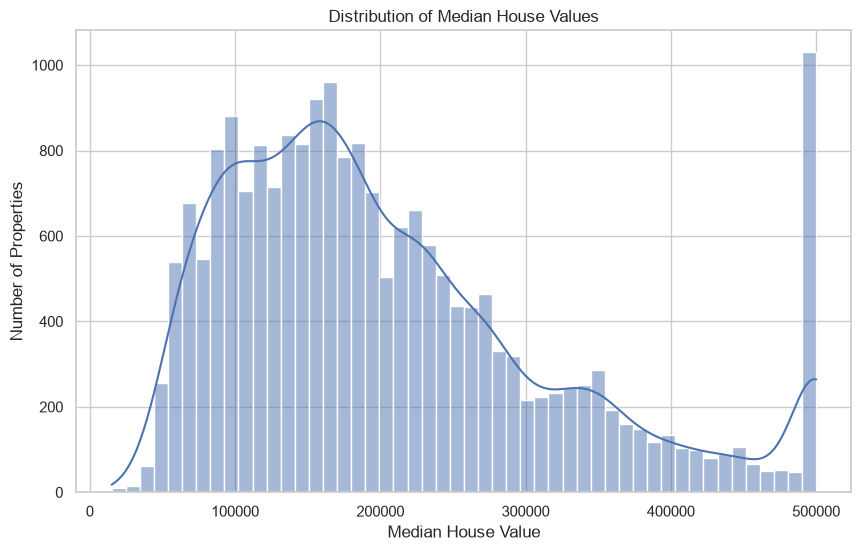

In [7]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="median_house_value",
    bins=50,
    kde=True
)

plt.title(
    "Distribution of Median House Values"
)

plt.xlabel(
    "Median House Value"
)

plt.ylabel(
    "Number of Properties"
)

plt.show()

In [8]:
# Target Variable Statistics

target_statistics = pd.DataFrame({
    "Mean": [
        df["median_house_value"].mean()
    ],
    "Median": [
        df["median_house_value"].median()
    ],
    "Standard Deviation": [
        df["median_house_value"].std()
    ],
    "Minimum": [
        df["median_house_value"].min()
    ],
    "Maximum": [
        df["median_house_value"].max()
    ]
})

display(
    target_statistics.round(2)
)

,Mean,Median,Standard Deviation,Minimum,Maximum
0,206855.82,179700.0,115395.62,14999.0,500001.0


### Observation

The distribution of `median_house_value` provides an overview of housing prices within the dataset.

The distribution should be considered when interpreting the model results because extreme property values and a potentially skewed target distribution may affect the performance of Linear Regression.

The model developed in this project uses the original house-price values to maintain straightforward interpretation of the predicted output.


## 5. Feature Selection

The following features were selected as potential predictors of house prices based on their logical relationship with housing value.

### Location Features

- `longitude`
- `latitude`
- `ocean_proximity`

Location is expected to influence house prices because properties in different geographical areas and locations near desirable environments may have different market values.

### Property Age

- `housing_median_age`

The age of housing may influence property value because newer and older properties can have different levels of demand and quality.

### Property Size Indicators

- `total_rooms`
- `total_bedrooms`
- `households`

The dataset does not contain a direct property-area measurement. Therefore, the number of rooms and bedrooms are used as proxy indicators of property size and housing characteristics.

### Economic Feature

- `median_income`

Median income may be associated with house prices because higher-income areas may contain more valuable properties.

### Population Features

- `population`

Population may provide information about the density and characteristics of a geographical area.

The categorical feature `ocean_proximity` will be transformed using One-Hot Encoding before model training.

## 6. Correlation Analysis


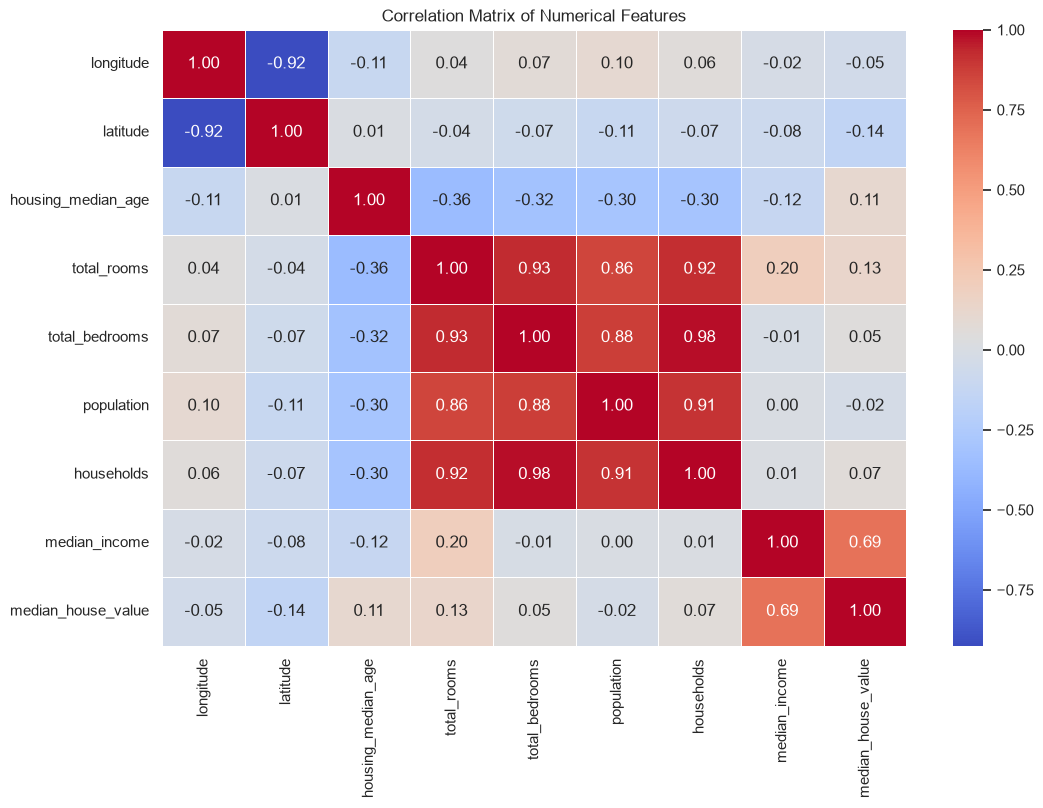

In [9]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns

correlation_matrix = (
    df[numerical_columns]
    .corr()
)

plt.figure(
    figsize=(12, 8)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Numerical Features"
)

plt.show()

In [10]:
# Features Most Correlated With Price

price_correlations = (
    correlation_matrix[
        "median_house_value"
    ]
    .drop(
        "median_house_value"
    )
    .sort_values(
        ascending=False
    )
)

print(
    "Features Most Positively Correlated With House Price:"
)

display(
    price_correlations.head()
)

print(
    "\nFeatures Most Negatively Correlated With House Price:"
)

display(
    price_correlations.sort_values().head()
)

Features Most Positively Correlated With House Price:


median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
Name: median_house_value, dtype: float64


Features Most Negatively Correlated With House Price:


latitude         -0.144160
longitude        -0.045967
population       -0.024650
total_bedrooms    0.049686
households        0.065843
Name: median_house_value, dtype: float64

### Observation

The correlation analysis identifies the numerical variables that have the strongest linear relationships with house prices.

Features with a positive correlation tend to increase alongside house prices, while features with a negative correlation tend to decrease as house prices increase.

Correlation does not prove that one variable directly causes changes in house prices. However, it provides useful information for feature selection and model interpretation.

## 7. Preparing Features and Target Variable

In [11]:
TARGET = "median_house_value"

X = df.drop(
    columns=TARGET
)

y = df[TARGET]

print("Feature Matrix Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape: (20640, 9)
Target Variable Shape: (20640,)


In [12]:
# Identify Numerical and Categorical Features

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(
    "Numerical Features:"
)

print(
    numeric_features
)

print(
    "\nCategorical Features:"
)

print(
    categorical_features
)

Numerical Features:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

Categorical Features:
['ocean_proximity']


## 8. Data Preprocessing

In [13]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print(
    "Preprocessing pipeline created successfully."
)

Preprocessing pipeline created successfully.


## 9. Train and Test Split

The dataset is divided into:

- 80% training data
- 20% testing data

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(
    "Training Features Shape:",
    X_train.shape
)

print(
    "Testing Features Shape:",
    X_test.shape
)

print(
    "Training Target Shape:",
    y_train.shape
)

print(
    "Testing Target Shape:",
    y_test.shape
)

Training Features Shape: (16512, 9)
Testing Features Shape: (4128, 9)
Training Target Shape: (16512,)
Testing Target Shape: (4128,)


## 10. Linear Regression Model
Linear Regression models the relationship between the predictor variables and the target variable.

The model attempts to identify the best linear relationship between the selected housing features and median house prices.

In [15]:
linear_regression_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

linear_regression_pipeline.fit(
    X_train,
    y_train
)

print(
    "Linear Regression model trained successfully."
)

Linear Regression model trained successfully.


In [16]:
# Generate Predictions

y_pred = linear_regression_pipeline.predict(
    X_test
)

prediction_results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

display(
    prediction_results.head(10)
)

,Actual Price,Predicted Price
0,47700.0,54261.027690
1,45800.0,124430.917728
2,500001.0,255694.958282
3,218600.0,268208.010360
4,278000.0,262975.013606
5,158700.0,139811.882746
6,198200.0,290871.002705
7,157500.0,228470.455166
8,340000.0,256712.364401
9,446600.0,408129.437226


## 11. Model Evaluation


In [17]:
mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mse
)

r2 = r2_score(
    y_test,
    y_pred
)

evaluation_results = pd.DataFrame({
    "Metric": [
        "Mean Squared Error (MSE)",
        "Root Mean Squared Error (RMSE)",
        "R² Score"
    ],
    "Value": [
        mse,
        rmse,
        r2
    ]
})

display(
    evaluation_results.round(4)
)

,Metric,Value
0,Mean Squared Error (MSE),4.908291e+09
1,Root Mean Squared Error (RMSE),7.005919e+04
2,R² Score,6.254000e-01


### Interpretation

The model evaluation metrics provide different perspectives on prediction performance.

A lower MSE and RMSE indicate smaller prediction errors, while a higher R² score indicates that the model explains a greater proportion of variation in house prices.

The results should be interpreted together rather than relying on only one evaluation metric.

## 12. Actual Versus Predicted House Prices

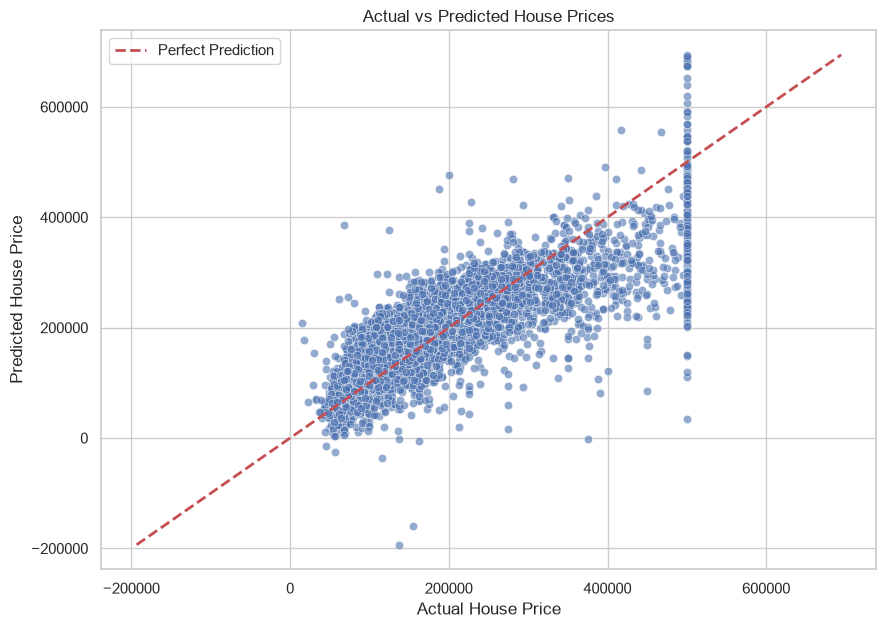

In [18]:
plt.figure(
    figsize=(10, 7)
)

sns.scatterplot(
    x=y_test,
    y=y_pred,
    alpha=0.6
)

minimum_value = min(
    y_test.min(),
    y_pred.min()
)

maximum_value = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [
        minimum_value,
        maximum_value
    ],
    [
        minimum_value,
        maximum_value
    ],
    "r--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title(
    "Actual vs Predicted House Prices"
)

plt.xlabel(
    "Actual House Price"
)

plt.ylabel(
    "Predicted House Price"
)

plt.legend()

plt.show()

### Observation

The closer the observations are to the diagonal reference line, the closer the predicted values are to the actual house prices.

Points located far from the line represent larger prediction errors.

The overall pattern of the scatter plot provides a visual assessment of the predictive performance of the Linear Regression model.

## 13. Residual Analysis

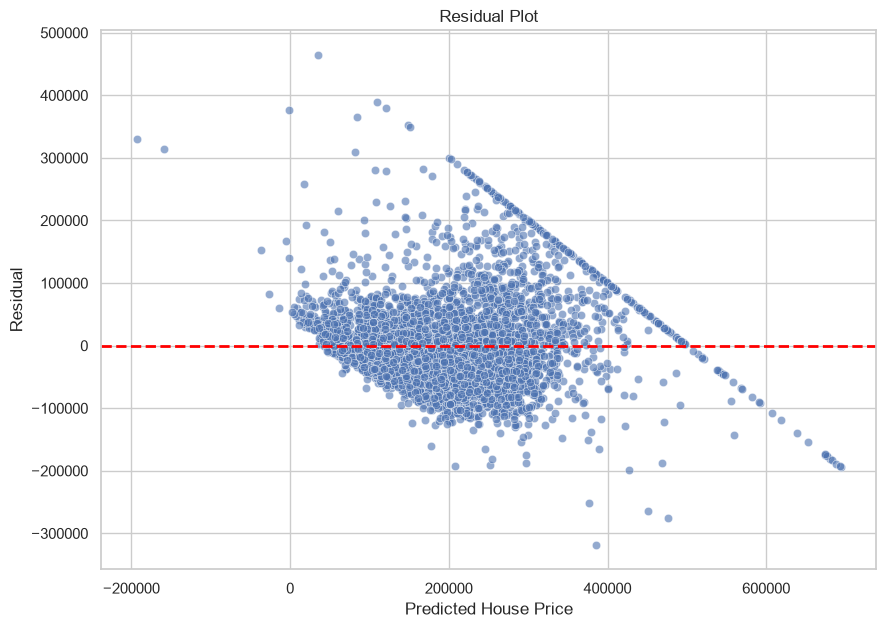

In [19]:
residuals = (
    y_test - y_pred
)

plt.figure(
    figsize=(10, 7)
)

sns.scatterplot(
    x=y_pred,
    y=residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title(
    "Residual Plot"
)

plt.xlabel(
    "Predicted House Price"
)

plt.ylabel(
    "Residual"
)

plt.show()

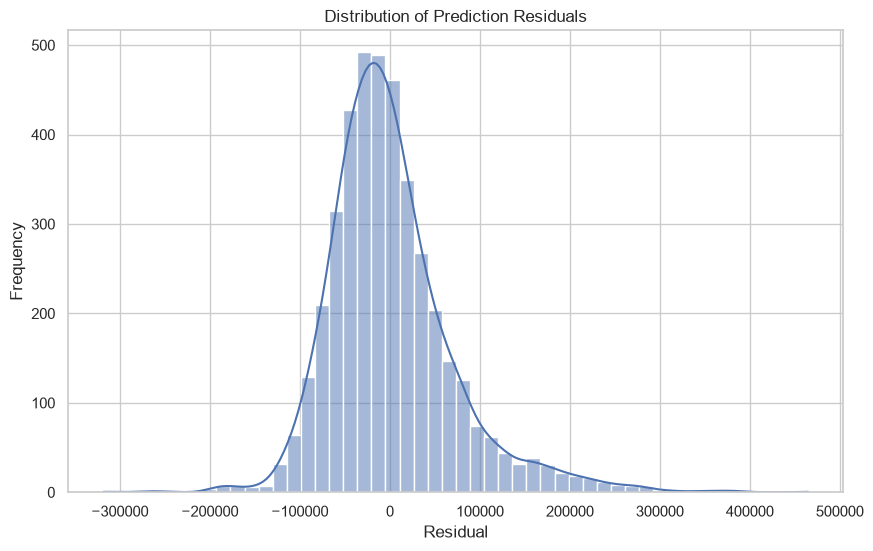

In [20]:
# Residual Distribution

plt.figure(
    figsize=(10, 6)
)

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.title(
    "Distribution of Prediction Residuals"
)

plt.xlabel(
    "Residual"
)

plt.ylabel(
    "Frequency"
)

plt.show()

## 14. Coefficient Analysis


In [21]:
fitted_preprocessor = (
    linear_regression_pipeline.named_steps[
        "preprocessor"
    ]
)

feature_names = (
    fitted_preprocessor.get_feature_names_out()
)

coefficients = (
    linear_regression_pipeline.named_steps[
        "model"
    ].coef_
)

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df[
    "Absolute_Coefficient"
] = (
    coefficient_df[
        "Coefficient"
    ].abs()
)

coefficient_df = (
    coefficient_df
    .sort_values(
        by="Absolute_Coefficient",
        ascending=False
    )
)

display(
    coefficient_df.head(15)
)

,Feature,Coefficient,Absolute_Coefficient
9,categorical__ocean_proximity_ISLAND,136125.072615,136125.072615
7,numeric__median_income,75167.774766,75167.774766
1,numeric__latitude,-54415.696144,54415.696144
0,numeric__longitude,-53826.648016,53826.648016
5,numeric__population,-43403.432427,43403.432427
4,numeric__total_bedrooms,43068.181842,43068.181842
8,categorical__ocean_proximity_INLAND,-39786.656161,39786.656161
6,numeric__households,18382.196324,18382.196324
2,numeric__housing_median_age,13889.866189,13889.866189
3,numeric__total_rooms,-13094.251162,13094.251162


In [22]:
# Highest Positive and Negative Features

positive_coefficients = (
    coefficient_df[
        coefficient_df[
            "Coefficient"
        ] > 0
    ]
    .sort_values(
        "Coefficient",
        ascending=False
    )
)

negative_coefficients = (
    coefficient_df[
        coefficient_df[
            "Coefficient"
        ] < 0
    ]
    .sort_values(
        "Coefficient"
    )
)

print(
    "Top 10 Features With the Highest Positive Impact:"
)

display(
    positive_coefficients[
        [
            "Feature",
            "Coefficient"
        ]
    ].head(10)
)

print(
    "\nTop 10 Features With the Highest Negative Impact:"
)

display(
    negative_coefficients[
        [
            "Feature",
            "Coefficient"
        ]
    ].head(10)
)

Top 10 Features With the Highest Positive Impact:


,Feature,Coefficient
9,categorical__ocean_proximity_ISLAND,136125.072615
7,numeric__median_income,75167.774766
4,numeric__total_bedrooms,43068.181842
6,numeric__households,18382.196324
2,numeric__housing_median_age,13889.866189
11,categorical__ocean_proximity_NEAR OCEAN,3431.140073



Top 10 Features With the Highest Negative Impact:


,Feature,Coefficient
1,numeric__latitude,-54415.696144
0,numeric__longitude,-53826.648016
5,numeric__population,-43403.432427
8,categorical__ocean_proximity_INLAND,-39786.656161
3,numeric__total_rooms,-13094.251162
10,categorical__ocean_proximity_NEAR BAY,-5136.642217


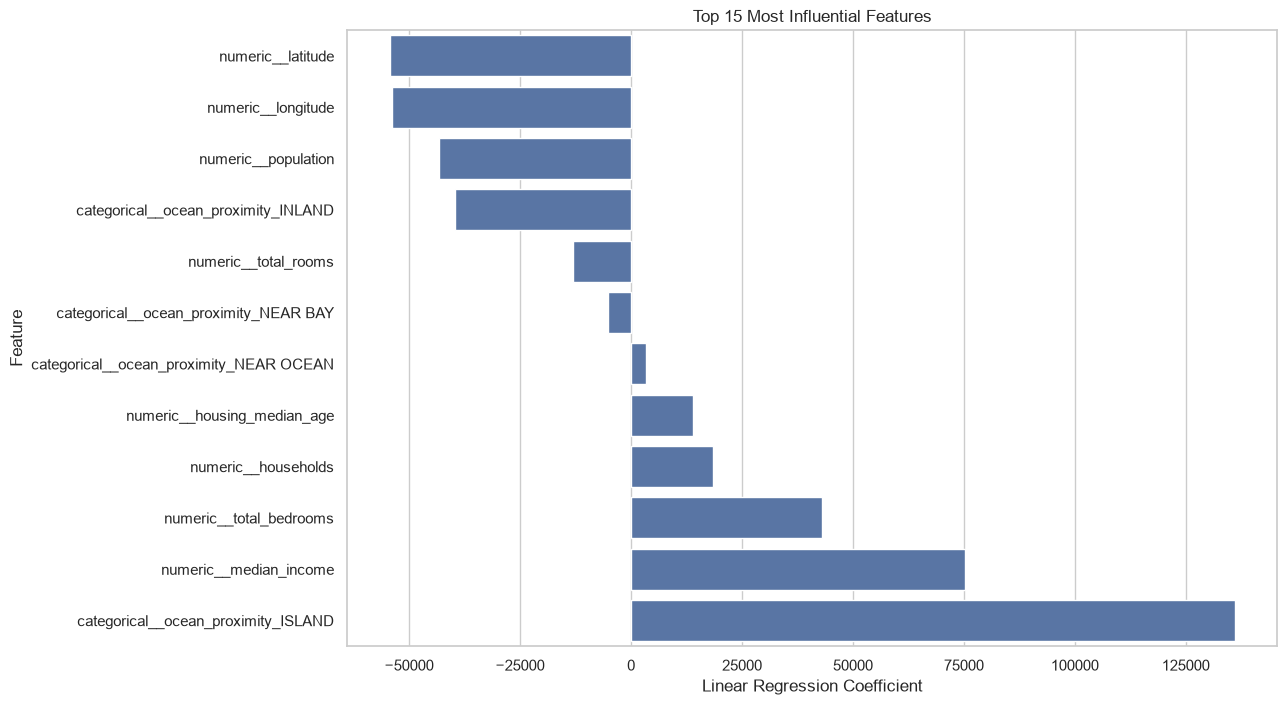

In [23]:
# Coefficient Visualisation

top_coefficients = (
    coefficient_df
    .head(15)
    .sort_values(
        "Coefficient"
    )
)

plt.figure(
    figsize=(12, 8)
)

sns.barplot(
    data=top_coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title(
    "Top 15 Most Influential Features"
)

plt.xlabel(
    "Linear Regression Coefficient"
)

plt.ylabel(
    "Feature"
)

plt.show()

### Interpretation

The coefficient analysis identifies the features with the strongest positive and negative relationships with predicted house prices within the Linear Regression model.

Features with larger absolute coefficient values have a stronger influence on model predictions after preprocessing.

However, these coefficients should not automatically be interpreted as causal relationships. They describe associations identified by the model based on the available dataset.

## 15. Bonus: Ridge Regression Comparison


In [24]:
ridge_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            Ridge(
                alpha=1.0
            )
        )
    ]
)

ridge_pipeline.fit(
    X_train,
    y_train
)

ridge_predictions = (
    ridge_pipeline.predict(
        X_test
    )
)

ridge_mse = mean_squared_error(
    y_test,
    ridge_predictions
)

ridge_rmse = np.sqrt(
    ridge_mse
)

ridge_r2 = r2_score(
    y_test,
    ridge_predictions
)

In [25]:
# Compare Linear Regression and Ridge

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression"
    ],
    "MSE": [
        mse,
        ridge_mse
    ],
    "RMSE": [
        rmse,
        ridge_rmse
    ],
    "R² Score": [
        r2,
        ridge_r2
    ]
})

display(
    model_comparison.round(4)
)

,Model,MSE,RMSE,R² Score
0,Linear Regression,4.908291e+09,70059.1933,0.6254
1,Ridge Regression,4.909452e+09,70067.4812,0.6253


### Model Comparison

The Linear Regression and Ridge Regression models are compared using MSE, RMSE and R² scores.

The model with the lower prediction error and higher R² score can generally be considered more effective for this dataset.

However, model selection should also consider interpretability and the purpose of the analysis.

# 16. Final Conclusion

This project developed and evaluated a Linear Regression model to predict median house values using housing characteristics, geographical location, property age, population-related variables, income and ocean proximity.

## Key Findings

### 1. House Prices Are Influenced by Multiple Factors

The analysis demonstrates that house prices are influenced by a combination of geographical, housing and economic factors. Therefore, using multiple predictor variables provides a more comprehensive approach to house price prediction than relying on a single feature.

### 2. Location and Economic Factors Are Important

The correlation and coefficient analyses identified important relationships between selected features and median house values. Geographical variables, ocean proximity and median income provide valuable information for predicting housing prices.

### 3. Linear Regression Provides a Useful Baseline Model

The Linear Regression model was evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE) and R² score. The Actual versus Predicted Price plot and residual analysis provided additional insights into the model's predictive performance.

### 4. Model Comparison Provides Additional Insights

The bonus comparison with Ridge Regression demonstrates how regularisation can be used as an alternative approach to Linear Regression. Comparing models using the same evaluation metrics helps identify the most suitable approach for the dataset.

## Final Recommendation

House price prediction should consider a combination of location, housing characteristics, property age and economic factors. Future improvements could include additional feature engineering, transformation of highly skewed variables and testing more advanced machine learning models.

Overall, this project demonstrates a complete machine learning workflow, from Exploratory Data Analysis and data preprocessing to model development, evaluation and interpretation.